In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
from pathlib import Path


(np.float64(0.0), np.float64(14.0), np.float64(0.0), np.float64(5.0))

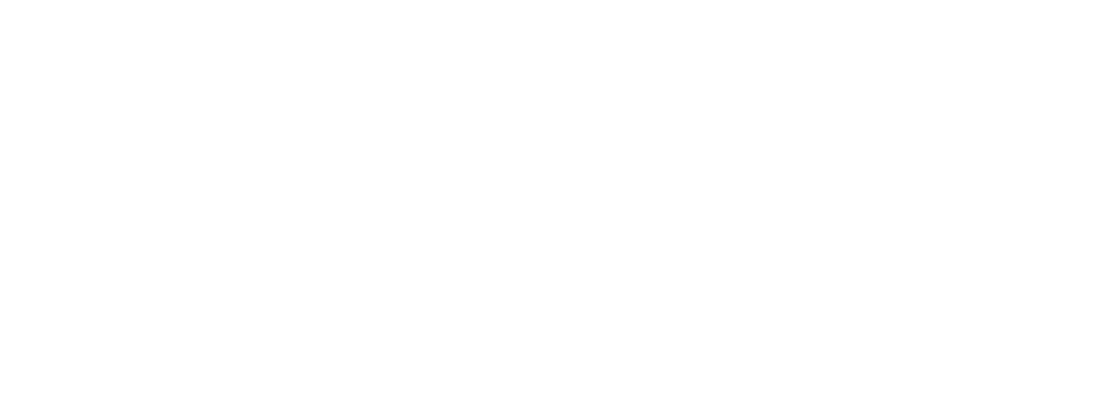

In [7]:


OUT_DIR = Path("kg_output")
OUT_DIR.mkdir(exist_ok=True)  # 加这行

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")



In [8]:


# ── 颜色定义 ──────────────────────────────────────────────
C_INPUT  = "#5B8DB8"   # 蓝：输入
C_PARSE  = "#20B2AA"   # 青：解析
C_ENCODE = "#3CB371"   # 绿：编码
C_IMG    = "#9B59B6"   # 紫：图像
C_REDUCE = "#E67E22"   # 橙：降维
C_OUTPUT = "#C0392B"   # 红：输出
C_ARROW  = "#555555"

# ── 节点定义 [label, sublabel, x_center, color] ──────────
NODES = [
    ("Raw Parquet",      "train + test\n689 samples",        1.0,  C_INPUT),
    ("JSON Parsing",     "11 biomarker\nfields extracted",   3.0,  C_PARSE),
    ("Feature Encoding", "bool→{0,1}\nCDR continuous",       5.0,  C_ENCODE),
    ("Image Loading",    "Fundus images\n178–408px",          3.0,  C_IMG),
    ("ResNet50",         "2048-dim\nembedding",               5.0,  C_IMG),
    ("PCA",              "2048→64\ndim reduction",            7.0,  C_REDUCE),
    ("StandardScaler",   "Zero mean\nunit variance",          9.0,  C_REDUCE),
    ("Feature Matrix",   "Bio + KG\nnode features",          11.5,  C_OUTPUT),
]

# 分两行：上行图像分支（y=3.2），下行文本分支（y=1.4），最后合并
# 重新定义带行信息的节点
# row: 0=top(image), 1=bottom(text), 2=merge
NODES_POS = [
    # label, sublabel, x, y, color
    ("Raw Parquet",      "train + test\n689 samples",   1.0,  2.5, C_INPUT),

    # 文本分支（下）
    ("JSON Parsing",     "11 biomarker\nfields",        3.2,  1.2, C_PARSE),
    ("Feature Encoding", "bool→{0,1}\nCDR continuous",  5.4,  1.2, C_ENCODE),

    # 图像分支（上）
    ("Image Loading",    "Fundus images\n178–408px",    3.2,  3.8, C_IMG),
    ("ResNet50",         "2048-dim\nembedding",          5.4,  3.8, C_IMG),
    ("PCA",              "2048→64-dim",                  7.5,  3.8, C_REDUCE),
    ("StandardScaler",   "Zero mean\nunit variance",     9.6,  3.8, C_REDUCE),

    # 합류
    ("Feature Matrix",   "Bio + KG\nnode features",    11.8,  2.5, C_OUTPUT),
]

BOX_W = 1.6
BOX_H = 0.9



In [9]:


def draw_box(ax, x, y, label, sublabel, color):
    box = FancyBboxPatch((x - BOX_W/2, y - BOX_H/2), BOX_W, BOX_H,
                          boxstyle="round,pad=0.08",
                          facecolor=color, edgecolor="white",
                          linewidth=1.5, zorder=3)
    ax.add_patch(box)
    ax.text(x, y + 0.15, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white", zorder=4)
    ax.text(x, y - 0.18, sublabel, ha="center", va="center",
            fontsize=7.5, color="white", alpha=0.92, zorder=4,
            linespacing=1.3)

def draw_arrow(ax, x1, y1, x2, y2, color=C_ARROW, style="->"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color,
                                lw=1.5, connectionstyle="arc3,rad=0.0"),
                zorder=2)



In [10]:


# 画所有节点
for label, sublabel, x, y, color in NODES_POS:
    draw_box(ax, x, y, label, sublabel, color)

# ── 箭头 ──────────────────────────────────────────────────
# Raw → JSON (下分支)
draw_arrow(ax, 1.0+BOX_W/2, 2.5-0.2, 3.2-BOX_W/2, 1.2)
# Raw → Image Loading (上分支)
draw_arrow(ax, 1.0+BOX_W/2, 2.5+0.2, 3.2-BOX_W/2, 3.8)

# 下分支内部
draw_arrow(ax, 3.2+BOX_W/2, 1.2, 5.4-BOX_W/2, 1.2)

# 上分支内部
draw_arrow(ax, 3.2+BOX_W/2, 3.8, 5.4-BOX_W/2, 3.8)
draw_arrow(ax, 5.4+BOX_W/2, 3.8, 7.5-BOX_W/2, 3.8)
draw_arrow(ax, 7.5+BOX_W/2, 3.8, 9.6-BOX_W/2, 3.8)

# 上分支 → Feature Matrix
draw_arrow(ax, 9.6+BOX_W/2, 3.8, 11.8-BOX_W/2, 2.5+0.2)
# 下分支 → Feature Matrix
draw_arrow(ax, 5.4+BOX_W/2, 1.2, 11.8-BOX_W/2, 2.5-0.2)

# ── 分支标签 ─────────────────────────────────────────────
ax.text(2.1, 3.35, "Image\nbranch", ha="center", fontsize=8,
        color=C_IMG, style="italic")
ax.text(2.1, 1.65, "Text\nbranch", ha="center", fontsize=8,
        color=C_PARSE, style="italic")

# ── 图例 ─────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_INPUT,  label="Input"),
    mpatches.Patch(color=C_PARSE,  label="Parsing"),
    mpatches.Patch(color=C_ENCODE, label="Encoding"),
    mpatches.Patch(color=C_IMG,    label="Image processing"),
    mpatches.Patch(color=C_REDUCE, label="Dimensionality reduction"),
    mpatches.Patch(color=C_OUTPUT, label="Output"),
]
ax.legend(handles=legend_items, loc="lower center",
          ncol=6, fontsize=8, framealpha=0.9,
          bbox_to_anchor=(0.5, -0.02))

ax.set_title("Data Preprocessing Pipeline", fontsize=13,
             fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "pipeline_data_preprocessing.png",
            dpi=200, bbox_inches="tight")
plt.savefig(OUT_DIR / "pipeline_data_preprocessing.pdf",
            bbox_inches="tight")
plt.show()
print("Saved: kg_output/pipeline_data_preprocessing.png/.pdf")


<Figure size 640x480 with 0 Axes>

Saved: kg_output/pipeline_data_preprocessing.png/.pdf
